In [1]:
################################
# Notebook 09 – Visualisierungen
################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

# 1. Analysebasis laden
df = pd.read_csv("../data_clean/df_analysis_base.csv")

# 2. Ein Eintrag pro Gemeinde
df = df.drop_duplicates(subset="municipality_code")

# 3. Geo-Daten laden
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

# 4. Alte Geo-Spalten entfernen, falls vorhanden
df = df.drop(columns=["longitude", "latitude"], errors="ignore")

# 5. Geo-Infos mergen
df = df.merge(
    df_geo[["municipality_code", "province", "longitude", "latitude"]],
    on="municipality_code",
    how="left"
)

# 6. Kopie für Scatterplots
df_gemeenten = df.copy()

# 7. GeoDataFrame für Karten
df["geometry"] = df.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


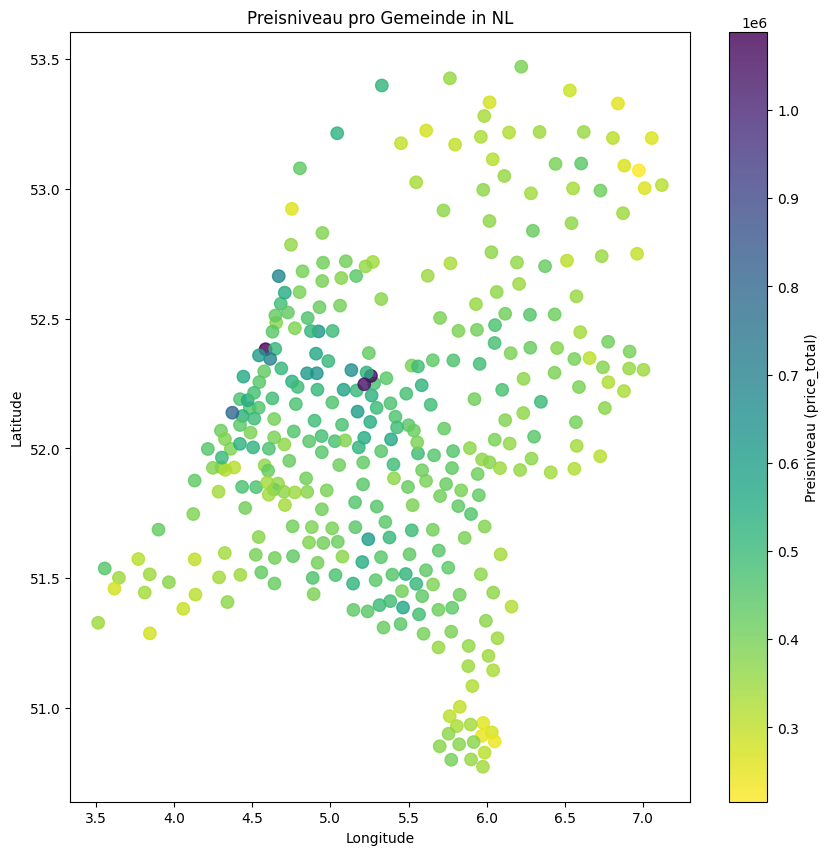

In [2]:
# -------------------------------------------
# Visual 1 – Preisniveau pro Gemeinde (Karte)
# -------------------------------------------

plt.figure(figsize=(10, 10))  # gleiche Größe wie Visual 2

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price_total"],
    cmap="viridis_r",   # Rot–Gelb–Grün (invertiert)
    s=80,
    alpha=0.8
)

plt.colorbar(label="Preisniveau (price_total)")
plt.title("Preisniveau pro Gemeinde in NL")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()



<Figure size 1000x1200 with 0 Axes>

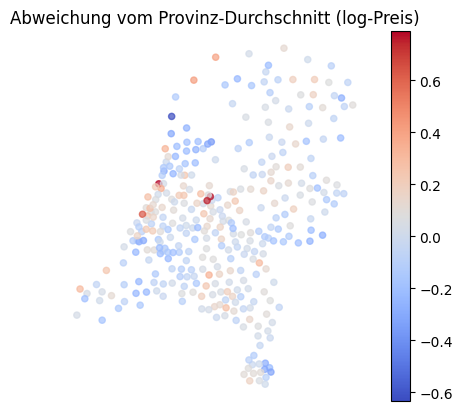

In [3]:
# ---------------------------------------------------------
# Visual 2 – Abweichung vom Provinz-Durchschnitt (Karte)
# ---------------------------------------------------------

# 1. Provinzmittel der log-Preise berechnen
province_means = df.groupby("province")["log_price_total"].mean()

# 2. Abweichung je Gemeinde berechnen
df["price_deviation_from_province"] = (
    df["log_price_total"] - df["province"].map(province_means)
)

# 3. GeoDataFrame NEU erzeugen (WICHTIG!)
df["geometry"] = df.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# 4. Plot
plt.figure(figsize=(10, 12))

gdf.plot(
    column="price_deviation_from_province",
    cmap="coolwarm",     # gewünschte Farbskala
    legend=True,
    markersize=20,
    alpha=0.7
)

plt.title("Abweichung vom Provinz-Durchschnitt (log-Preis)")
plt.axis("off")
plt.show()


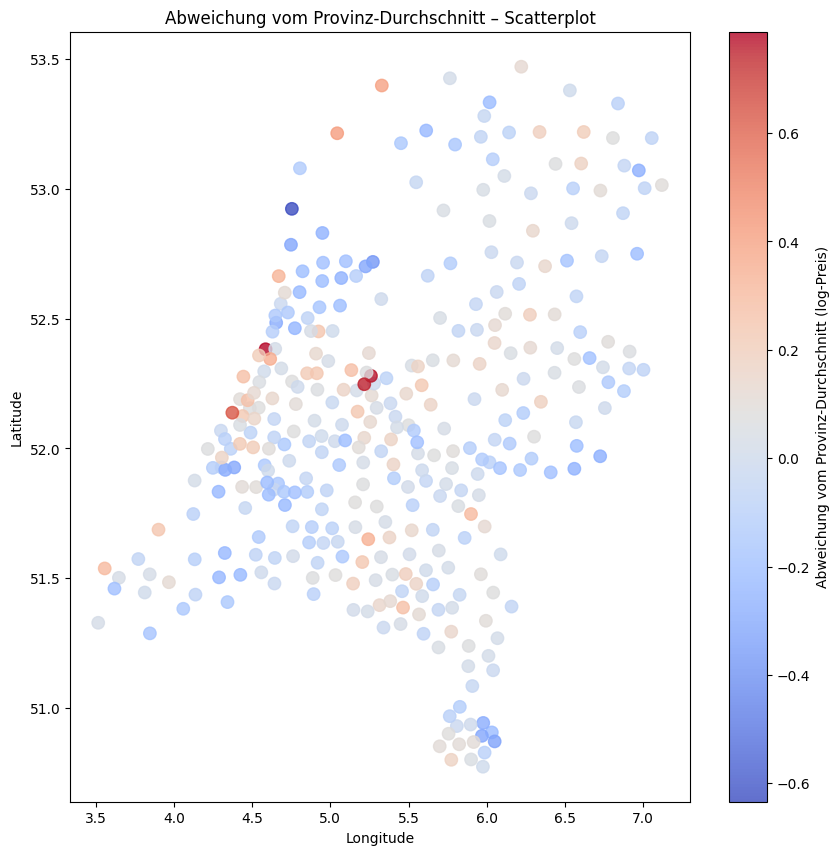

In [4]:
#-------------------------------------------------------------------
# Visual 2 – Abweichung vom Provinz-Durchschnitt (invertierte Skala)
# ------------------------------------------------------------------

plt.figure(figsize=(10, 10))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price_deviation_from_province"],
    cmap="coolwarm",
    s=80,
    alpha=0.8
)

plt.colorbar(label="Abweichung vom Provinz-Durchschnitt (log-Preis)")
plt.title("Abweichung vom Provinz-Durchschnitt – Scatterplot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


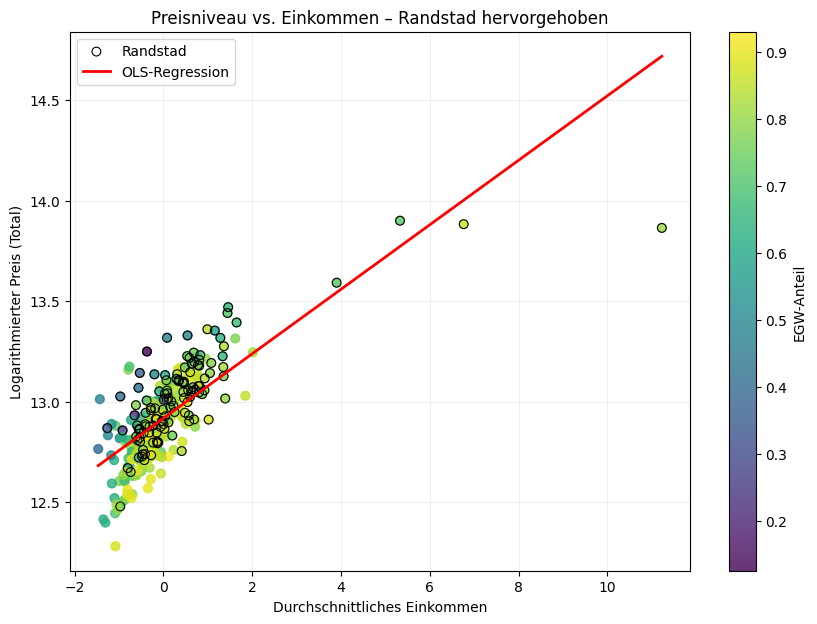

In [5]:
# ---------------------------------------------------------
# Visual 3 – Scatterplot: Preisniveau vs. Einkommen
# mit Regression & Randstad-Markierung
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Normalpunkte (alle Gemeinden)
scatter = plt.scatter(
    df_gemeenten["income_mean"],
    df_gemeenten["log_price_total"],
    c=df_gemeenten["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Randstad hervorheben (schwarzer Kreis)
randstad = df_gemeenten[df_gemeenten["is_randstad"] == 1]

plt.scatter(
    randstad["income_mean"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression
X = sm.add_constant(df_gemeenten["income_mean"])
y = df_gemeenten["log_price_total"]
model = sm.OLS(y, X).fit()

x_vals = np.linspace(
    df_gemeenten["income_mean"].min(),
    df_gemeenten["income_mean"].max(),
    200
)
y_pred = model.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS‑Regression"
)

# 4. Achsen, Titel, Legende
plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("Durchschnittliches Einkommen")
plt.ylabel("Logarithmierter Preis (Total)")
plt.title("Preisniveau vs. Einkommen – Randstad hervorgehoben")
plt.grid(alpha=0.2)
plt.legend()

plt.show()


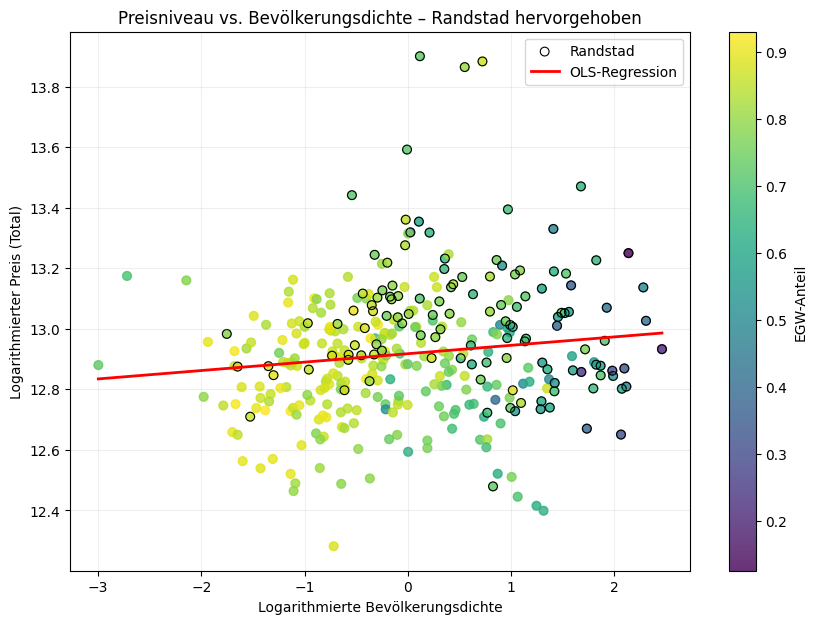

In [6]:
# ---------------------------------------------------------
# Visual 4 – Preisniveau vs. Bevölkerungsdichte
# mit Regression & Randstad-Markierung
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Normalpunkte (EGW-Farbskala)
scatter = plt.scatter(
    df_gemeenten["log_density"],
    df_gemeenten["log_price_total"],
    c=df_gemeenten["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Randstad hervorheben (schwarzer Kreis)
randstad = df_gemeenten[df_gemeenten["is_randstad"] == 1]

plt.scatter(
    randstad["log_density"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression (OLS)
X = sm.add_constant(df_gemeenten["log_density"])
y = df_gemeenten["log_price_total"]
model = sm.OLS(y, X).fit()

x_vals = np.linspace(
    df_gemeenten["log_density"].min(),
    df_gemeenten["log_density"].max(),
    200
)
y_pred = model.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS‑Regression"
)

# 4. Achsen, Titel, Layout
plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("Logarithmierte Bevölkerungsdichte")
plt.ylabel("Logarithmierter Preis (Total)")
plt.title("Preisniveau vs. Bevölkerungsdichte – Randstad hervorgehoben")
plt.grid(alpha=0.2)
plt.legend()

plt.show()


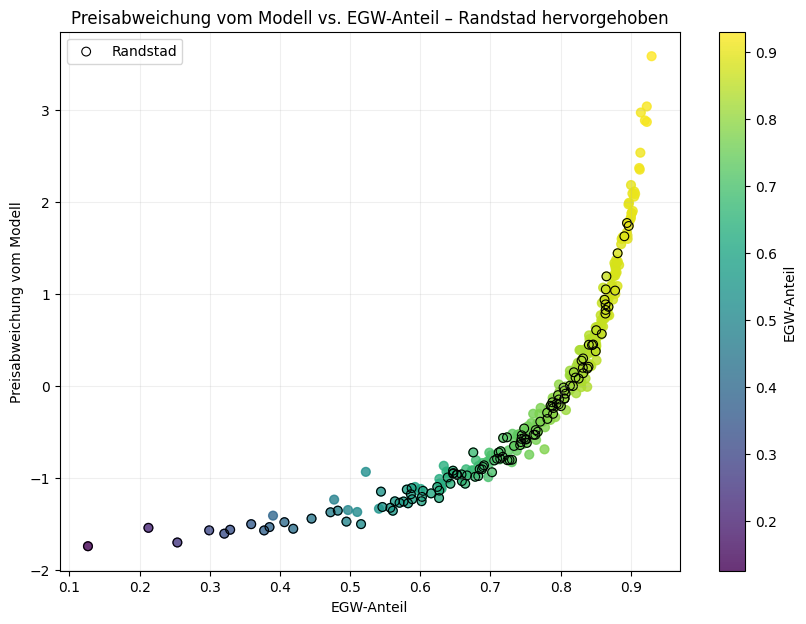

In [7]:
# ---------------------------------------------------------
# Visual 5 – Preisabweichung vom Modell vs. EGW-Anteil
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Normalpunkte (EGW-Farbskala)
scatter = plt.scatter(
    df_gemeenten["share_egw"],
    df_gemeenten["ratio_price_model"],
    c=df_gemeenten["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Randstad hervorheben (schwarzer Kreis)
randstad = df_gemeenten[df_gemeenten["is_randstad"] == 1]

plt.scatter(
    randstad["share_egw"],
    randstad["ratio_price_model"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression (optional – weiterhin auskommentiert)
# X = sm.add_constant(df_gemeenten["share_egw"])
# y = df_gemeenten["ratio_price_model"]
# model = sm.OLS(y, X).fit()
#
# x_vals = np.linspace(
#     df_gemeenten["share_egw"].min(),
#     df_gemeenten["share_egw"].max(),
#     200
# )
# y_pred = model.predict(sm.add_constant(x_vals))
#
# plt.plot(
#     x_vals,
#     y_pred,
#     color="red",
#     linewidth=2,
#     label="OLS‑Regression"
# )

# 4. Achsen, Titel, Layout
plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("EGW-Anteil")
plt.ylabel("Preisabweichung vom Modell")
plt.title("Preisabweichung vom Modell vs. EGW-Anteil – Randstad hervorgehoben")
plt.grid(alpha=0.2)
plt.legend()

plt.show()


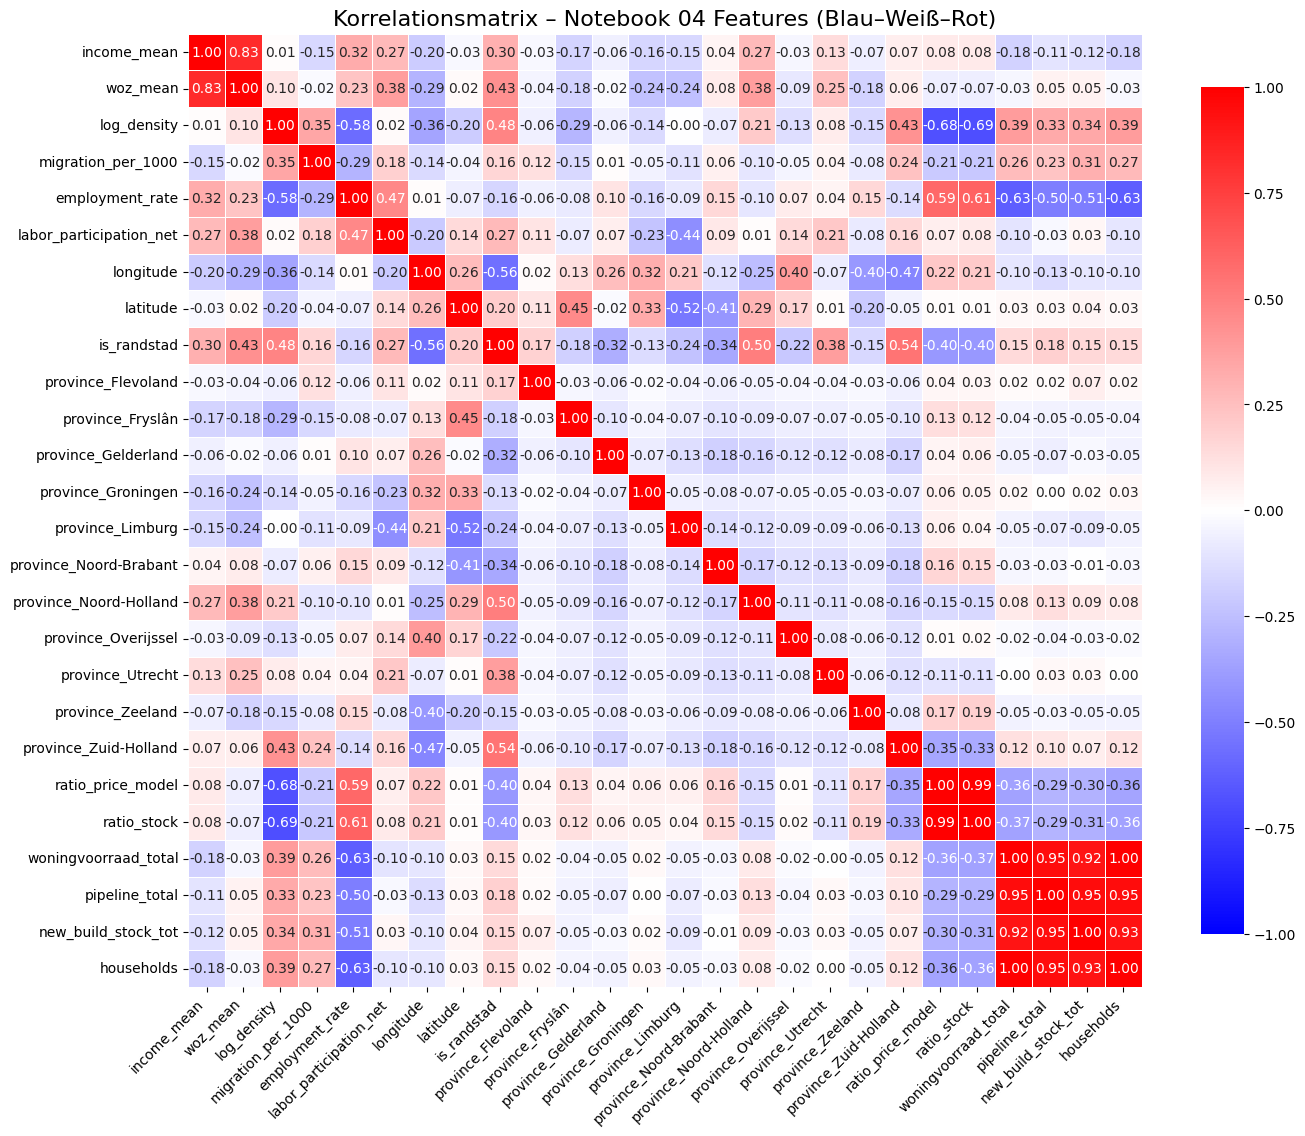

In [8]:
# ---------------------------------------------------------
# Visual 6.1 – Correlation Heatmap (Notebook 04 Features)
# Blau = -1, Weiß = 0, Rot = +1
# ---------------------------------------------------------

plt.figure(figsize=(14, 12))

# 1. Featureliste aus Notebook 04
features_nb04 = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'longitude',
    'latitude',
    'is_randstad',
    'province_Flevoland',
    'province_Fryslân',
    'province_Gelderland',
    'province_Groningen',
    'province_Limburg',
    'province_Noord-Brabant',
    'province_Noord-Holland',
    'province_Overijssel',
    'province_Utrecht',
    'province_Zeeland',
    'province_Zuid-Holland',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# 2. Korrelationsmatrix berechnen
corr = df_gemeenten[features_nb04].corr()

# 3. Heatmap zeichnen
sns.heatmap(
    corr,
    cmap="bwr",          # Blau–Weiß–Rot
    vmin=-1, vmax=1,     # feste Skala
    center=0,            # Weiß = 0
    annot=True,          # Zahlen anzeigen
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Korrelationsmatrix – Notebook 04 Features (Blau–Weiß–Rot)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


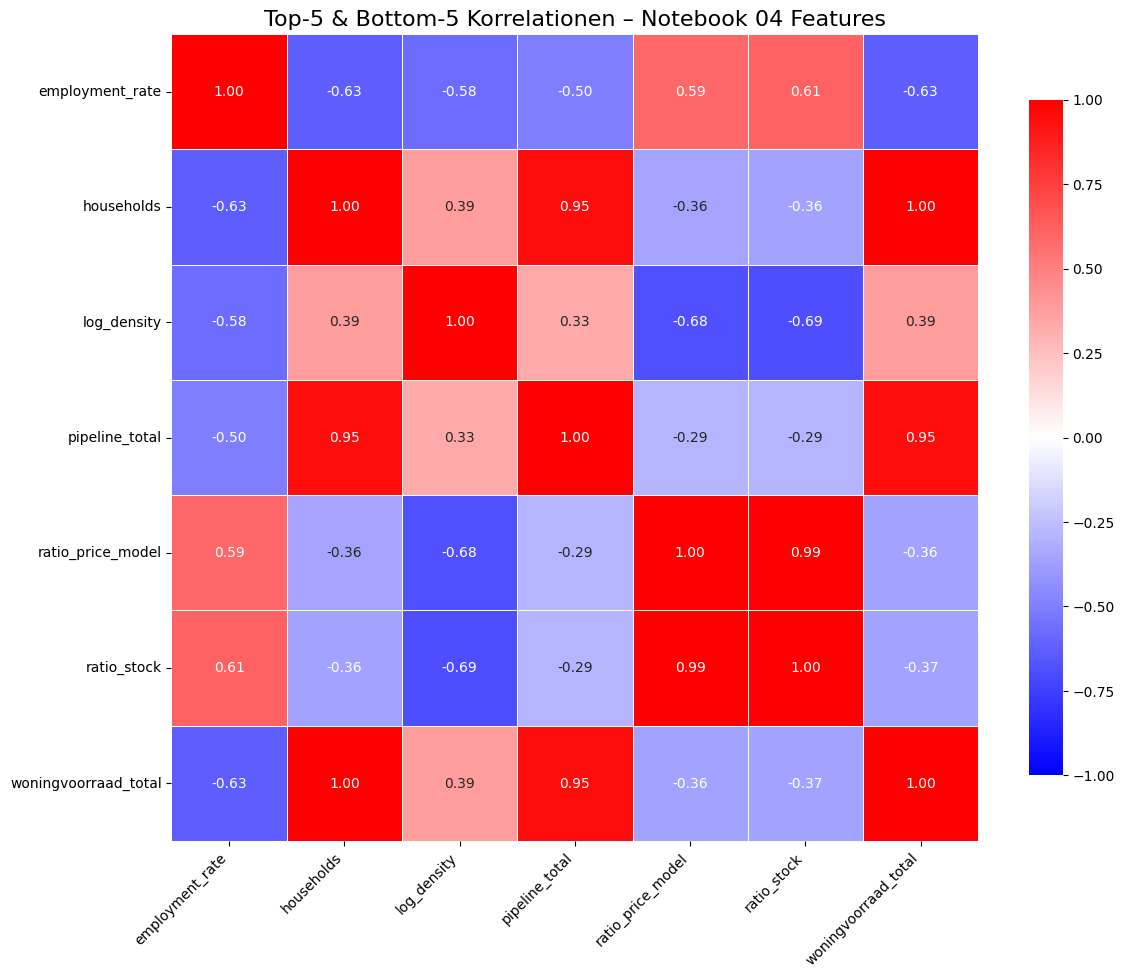

In [9]:
# ---------------------------------------------------------
# Visual 6b – Top-5 & Bottom-5 Korrelations-Heatmap
# ---------------------------------------------------------

plt.figure(figsize=(12, 10))

# 1. Featureliste aus Notebook 04
features_nb04 = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'longitude',
    'latitude',
    'is_randstad',
    'province_Flevoland',
    'province_Fryslân',
    'province_Gelderland',
    'province_Groningen',
    'province_Limburg',
    'province_Noord-Brabant',
    'province_Noord-Holland',
    'province_Overijssel',
    'province_Utrecht',
    'province_Zeeland',
    'province_Zuid-Holland',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# 2. Korrelationsmatrix
corr = df_gemeenten[features_nb04].corr()

# 3. Korrelationen in lange Form bringen
corr_long = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))  # Diagonale entfernen
        .stack()
        .reset_index()
)
corr_long.columns = ["var1", "var2", "corr"]

# 4. Top-5 und Bottom-5 auswählen
top5 = corr_long.nlargest(5, "corr")
bottom5 = corr_long.nsmallest(5, "corr")

selected_pairs = pd.concat([top5, bottom5])

# 5. Liste der beteiligten Variablen
selected_vars = sorted(set(selected_pairs["var1"]) | set(selected_pairs["var2"]))

# 6. Submatrix erstellen
corr_sub = corr.loc[selected_vars, selected_vars]

# 7. Heatmap zeichnen
sns.heatmap(
    corr_sub,
    cmap="bwr",
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Top‑5 & Bottom‑5 Korrelationen – Notebook 04 Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


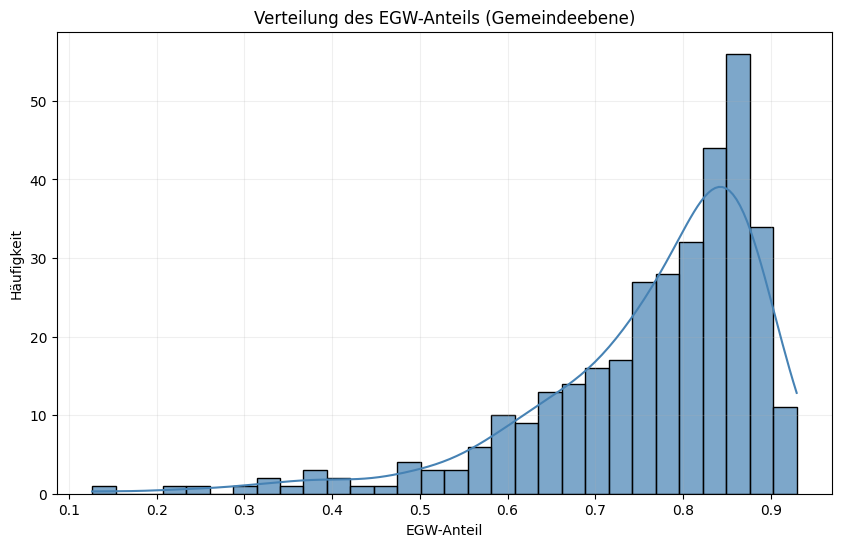

In [10]:
# ---------------------------------------------------------
# Visual 7 – Histogramm EGW-Anteil
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df_gemeenten["share_egw"],
    bins=30,
    kde=True,
    color="steelblue",
    alpha=0.7
)

plt.xlabel("EGW-Anteil")
plt.ylabel("Häufigkeit")
plt.title("Verteilung des EGW-Anteils (Gemeindeebene)")
plt.grid(alpha=0.2)

plt.show()


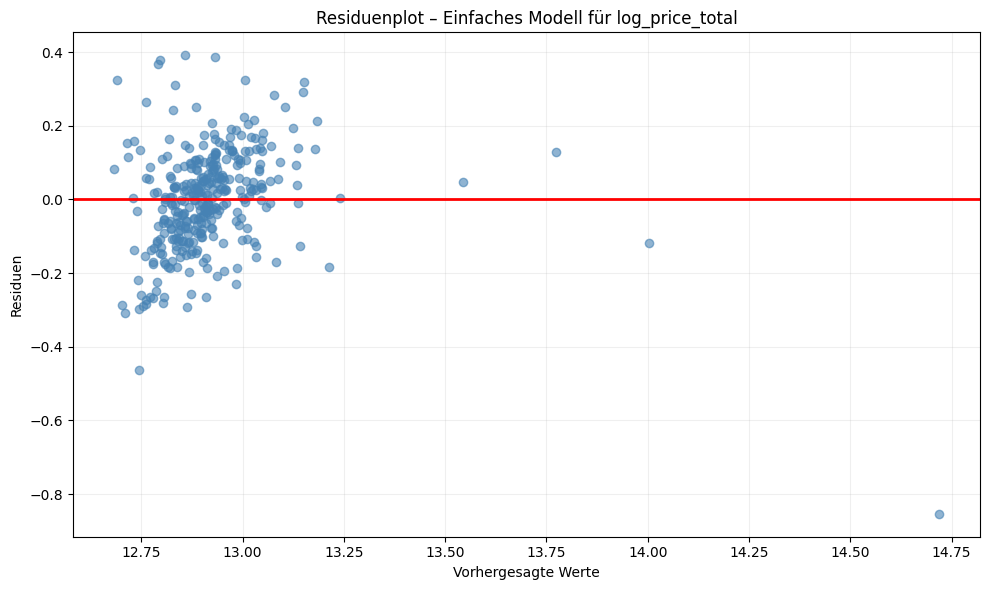

In [11]:
# ---------------------------------------------------------
# Visual 8 – Residuenplot (robust, unabhängig von Visual 7)
# ---------------------------------------------------------

# 1. Einfaches, garantiert numerisches Modell
X = df_gemeenten[["income_mean"]].apply(pd.to_numeric, errors="coerce")
X = sm.add_constant(X)
y = pd.to_numeric(df_gemeenten["log_price_total"], errors="coerce")

model_df = pd.concat([y, X], axis=1).dropna()
y_clean = model_df["log_price_total"]
X_clean = model_df.drop(columns=["log_price_total"])

model_total = sm.OLS(y_clean, X_clean).fit()

# 2. Residuen & Vorhersagen
residuals = model_total.resid
fitted = model_total.fittedvalues

# 3. Plot
plt.figure(figsize=(10, 6))

plt.scatter(fitted, residuals, alpha=0.6, color="steelblue")
plt.axhline(0, color="red", linewidth=2)

plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Residuen")
plt.title("Residuenplot – Einfaches Modell für log_price_total")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


<Figure size 1200x1200 with 0 Axes>

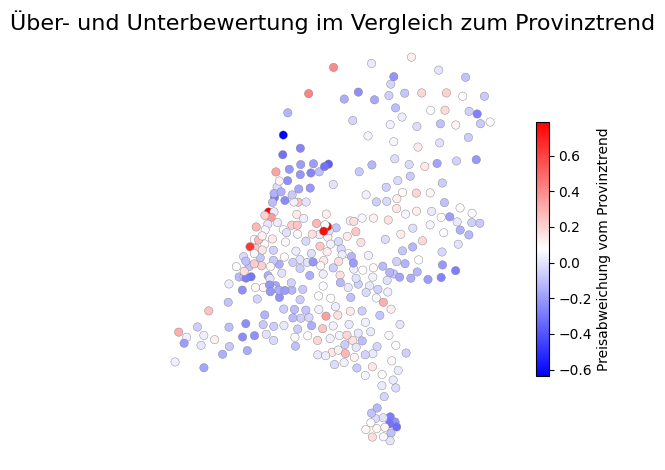

In [12]:
# ---------------------------------------------------------
# Visual 9 – Clusterkarte (Über-/Unterbewertung)
# ---------------------------------------------------------

plt.figure(figsize=(12, 12))

# Farbskala: Blau = unterbewertet, Rot = überbewertet
vmin = gdf["price_deviation_from_province"].min()
vmax = gdf["price_deviation_from_province"].max()

gdf.plot(
    column="price_deviation_from_province",
    cmap="bwr",
    linewidth=0.3,
    edgecolor="gray",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={"shrink": 0.6, "label": "Preisabweichung vom Provinztrend"}
)

plt.title("Über- und Unterbewertung im Vergleich zum Provinztrend", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


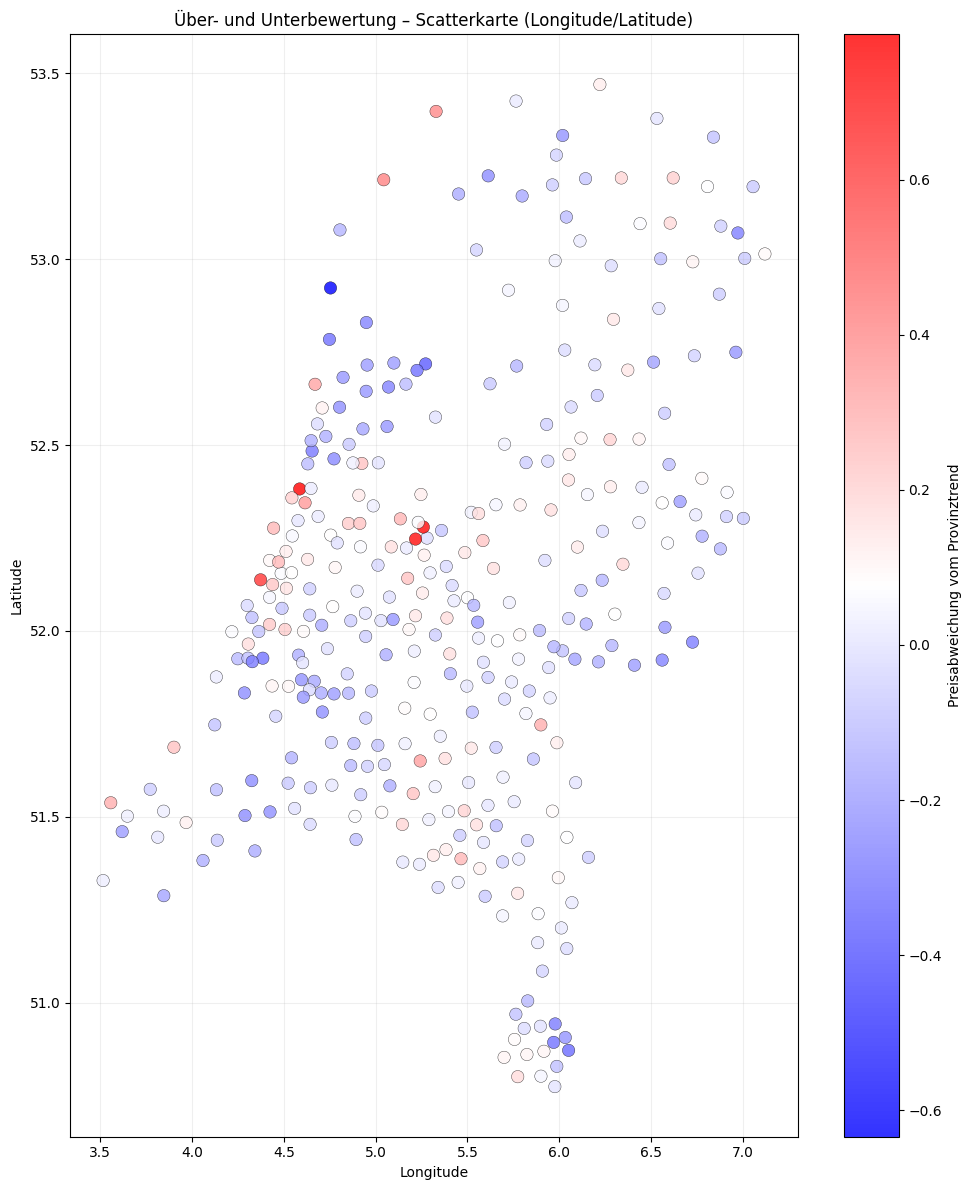

In [13]:
# ---------------------------------------------------------
# Visual 9 – Scatterkarte (Über-/Unterbewertung)
# ---------------------------------------------------------

plt.figure(figsize=(10, 12))

# Farbskala: Blau = unterbewertet, Rot = überbewertet
vmin = gdf["price_deviation_from_province"].min()
vmax = gdf["price_deviation_from_province"].max()

plt.scatter(
    gdf["longitude"],
    gdf["latitude"],
    c=gdf["price_deviation_from_province"],
    cmap="bwr",
    vmin=vmin,
    vmax=vmax,
    s=80,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.3
)

plt.colorbar(label="Preisabweichung vom Provinztrend")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Über- und Unterbewertung – Scatterkarte (Longitude/Latitude)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


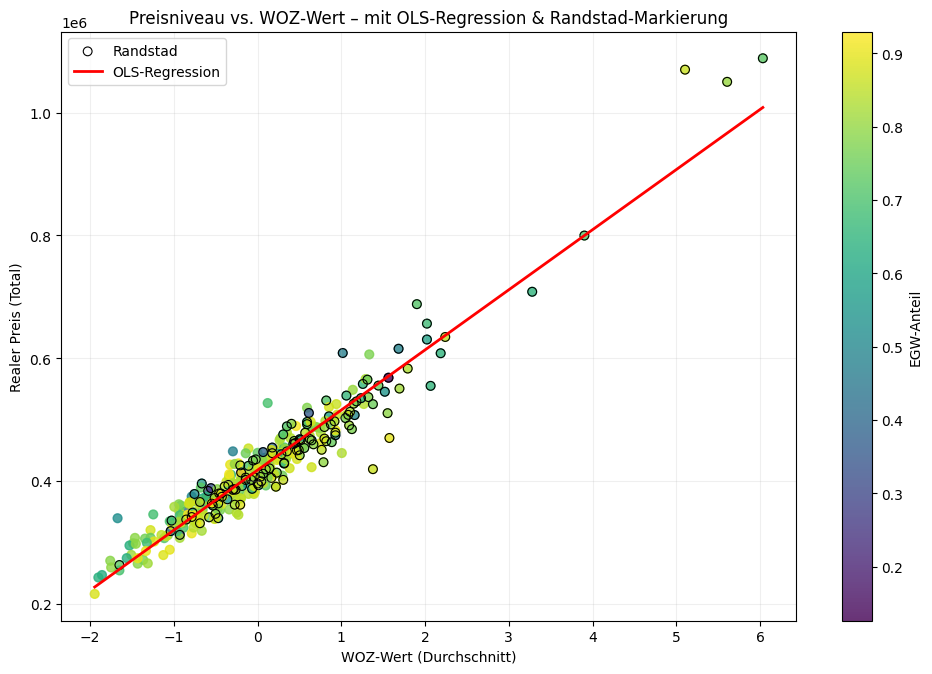

In [17]:
# ---------------------------------------------------------
# Visual 10 – Preis vs. WOZ (Scatter + Regression)
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatterplot (alle Gemeinden)
scatter = plt.scatter(
    df["woz_mean"],
    df["price_total"],
    c=df["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Randstad hervorheben (schwarzer Kreis)
randstad = df[df["is_randstad"] == 1]

plt.scatter(
    randstad["woz_mean"],
    randstad["price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression
X = sm.add_constant(df["woz_mean"])
y = df["price_total"]
model_woz = sm.OLS(y, X).fit()

x_vals = np.linspace(df["woz_mean"].min(), df["woz_mean"].max(), 200)
y_pred = model_woz.predict(sm.add_constant(x_vals))

# Achsenlimits (Beispiel)
#plt.xlim(randstad["woz_mean"].min(), randstad["woz_mean"].max())
#plt.ylim(randstad["price_total"].min(), randstad["price_total"].max())
#plt.xlim(df["woz_mean"].quantile(0.05), df["woz_mean"].quantile(0.99))
#plt.ylim(df["price_total"].quantile(0.05), df["price_total"].quantile(0.99))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS‑Regression"
)

# 4. Achsen, Titel, Legende
plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("WOZ‑Wert (Durchschnitt)")
plt.ylabel("Realer Preis (Total)")
plt.title("Preisniveau vs. WOZ‑Wert – mit OLS‑Regression & Randstad-Markierung")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


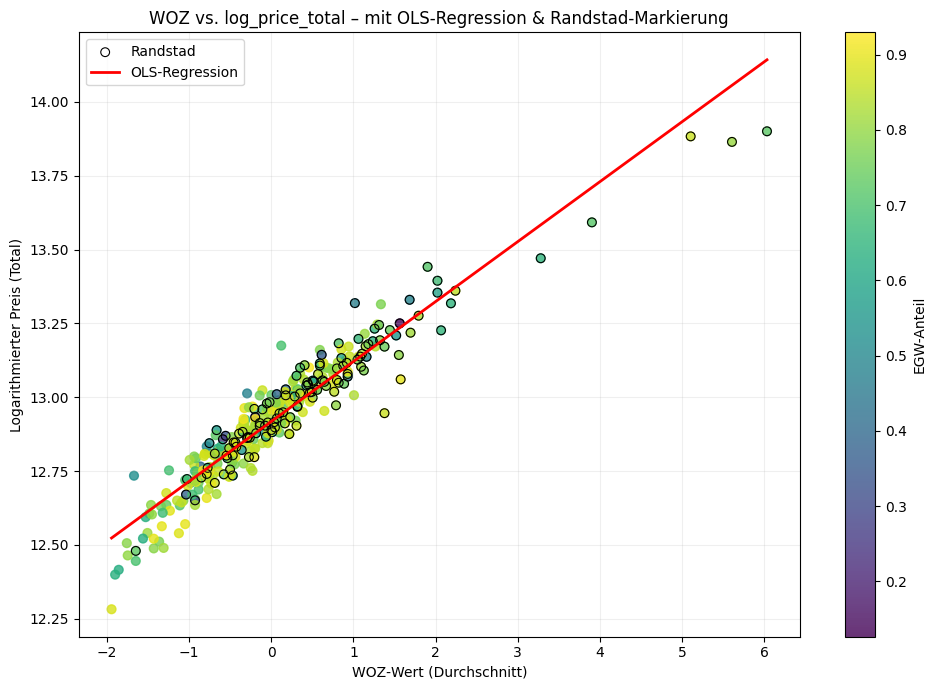

In [18]:
# ---------------------------------------------------------
# Visual 10‑log – WOZ vs. log_price_total (Scatter + Regression + Randstad)
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatterplot (alle Gemeinden)
scatter = plt.scatter(
    df["woz_mean"],
    df["log_price_total"],
    c=df["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Randstad hervorheben (schwarzer Kreis)
randstad = df[df["is_randstad"] == 1]

plt.scatter(
    randstad["woz_mean"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression
X = sm.add_constant(df["woz_mean"])
y = df["log_price_total"]
model_woz_log = sm.OLS(y, X).fit()

x_vals = np.linspace(df["woz_mean"].min(), df["woz_mean"].max(), 200)
y_pred = model_woz_log.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS‑Regression"
)

# 4. Achsen, Titel, Legende
plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("WOZ‑Wert (Durchschnitt)")
plt.ylabel("Logarithmierter Preis (Total)")
plt.title("WOZ vs. log_price_total – mit OLS‑Regression & Randstad-Markierung")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


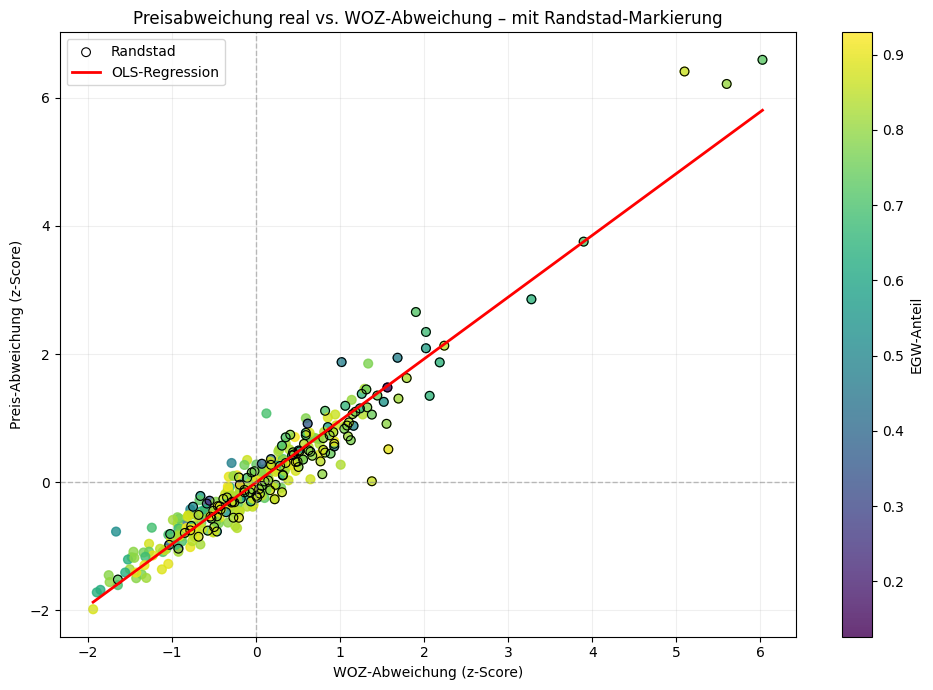

In [20]:
# ---------------------------------------------------------
# Visual 11 – Preisabweichung real vs. WOZ‑Abweichung
# ---------------------------------------------------------

# 1. Z‑Scores berechnen (falls noch nicht vorhanden)
df["z_price_total"] = (df["price_total"] - df["price_total"].mean()) / df["price_total"].std()
df["z_woz_mean"] = (df["woz_mean"] - df["woz_mean"].mean()) / df["woz_mean"].std()

plt.figure(figsize=(10, 7))

# 2. Scatterplot
scatter = plt.scatter(
    df["z_woz_mean"],
    df["z_price_total"],
    c=df["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 3. Randstad hervorheben
randstad = df[df["is_randstad"] == 1]

plt.scatter(
    randstad["z_woz_mean"],
    randstad["z_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 4. Regressionslinie
X = sm.add_constant(df["z_woz_mean"])
y = df["z_price_total"]
model_dev = sm.OLS(y, X).fit()

x_vals = np.linspace(df["z_woz_mean"].min(), df["z_woz_mean"].max(), 200)
y_pred = model_dev.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS‑Regression"
)

# 5. Achsen, Titel, Legende
plt.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linewidth=1, linestyle="--", alpha=0.5)

plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("WOZ‑Abweichung (z‑Score)")
plt.ylabel("Preis‑Abweichung (z‑Score)")
plt.title("Preisabweichung real vs. WOZ‑Abweichung – mit Randstad-Markierung")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


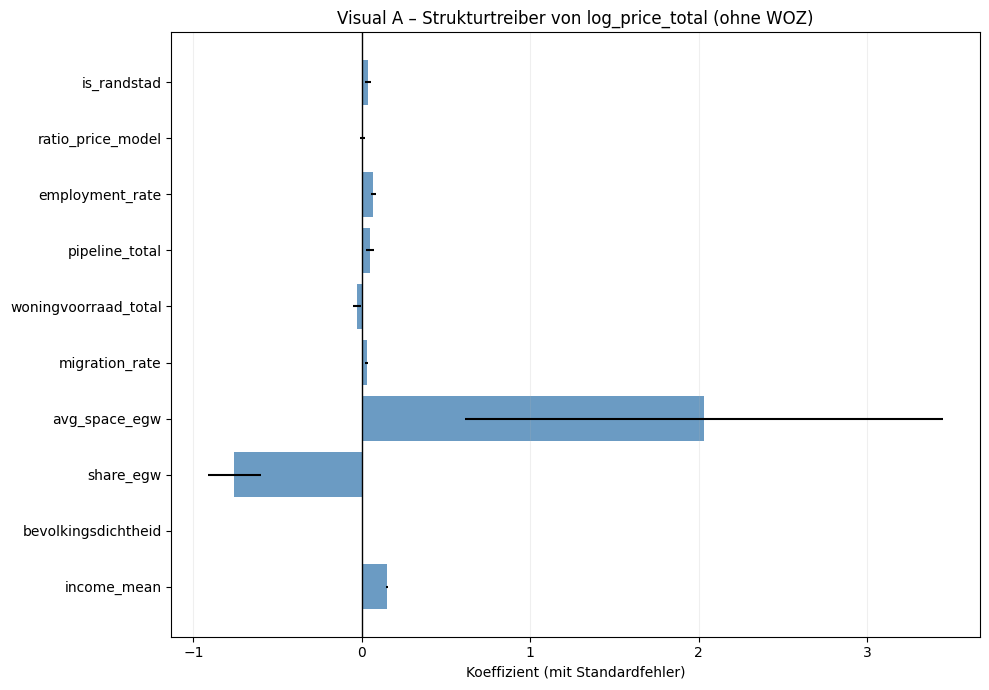

                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     67.23
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.64e-73
Time:                        11:23:40   Log-Likelihood:                 232.65
No. Observations:                 341   AIC:                            -443.3
Df Residuals:                     330   BIC:                            -401.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   11.4722 

In [24]:
# ---------------------------------------------------------
# Visual 12.1. – Strukturmodell: Was treibt log_price_total?
# ---------------------------------------------------------

import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Strukturvariablen definieren (ohne WOZ)
features_A = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "is_randstad"
]

X_A = df[features_A].copy()
X_A = sm.add_constant(X_A)
y_A = df["log_price_total"]

# 2. Modell schätzen
model_A = sm.OLS(y_A, X_A).fit()

# 3. Koeffizienten extrahieren
coef_A = model_A.params[1:]   # ohne Intercept
errors_A = model_A.bse[1:]    # Standardfehler

# 4. Visualisierung
plt.figure(figsize=(10, 7))

plt.barh(
    coef_A.index,
    coef_A.values,
    xerr=errors_A.values,
    color="steelblue",
    alpha=0.8
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Visual A – Strukturtreiber von log_price_total (ohne WOZ)")
plt.xlabel("Koeffizient (mit Standardfehler)")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 5. Modellgüte ausgeben
print(model_A.summary())


C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Anzahl Beobachtungen nach Bereinigung: 156


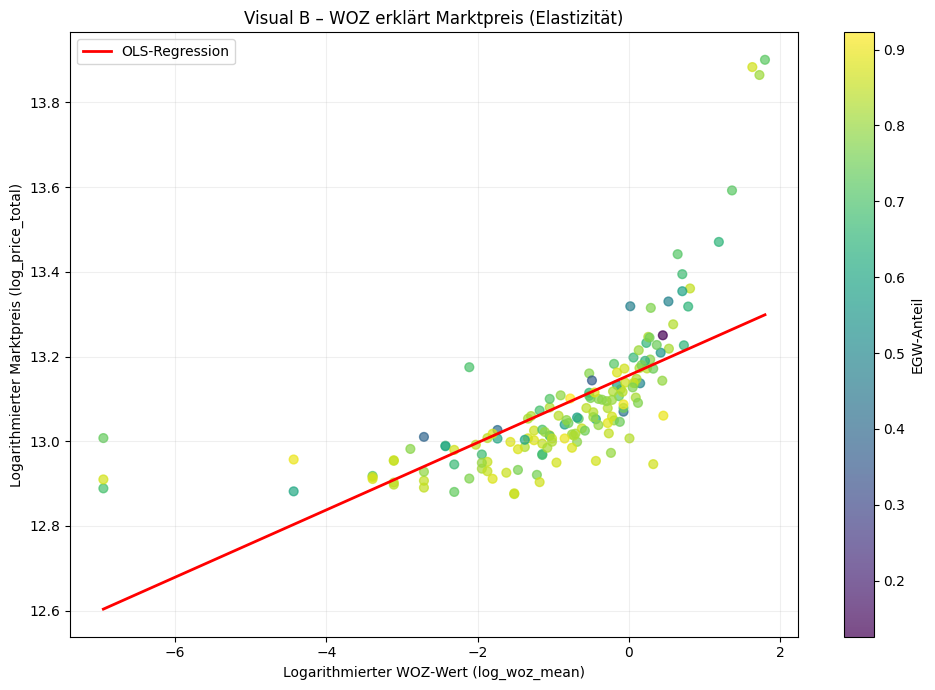

                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     127.1
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           7.12e-22
Time:                        11:30:41   Log-Likelihood:                 103.01
No. Observations:                 156   AIC:                            -202.0
Df Residuals:                     154   BIC:                            -195.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           13.1558      0.012   1102.905   

In [29]:
# ---------------------------------------------------------
# Visual 12.2. – WOZ erklärt Marktpreis (Elastizitätsmodell)
# Robuste Version mit Datenbereinigung
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Log-Variablen anlegen (falls noch nicht vorhanden)
df["log_price_total"] = np.log(df["price_total"])
df["log_woz_mean"] = np.log(df["woz_mean"])

# 2. Relevante Spalten auswählen
cols_B = ["log_price_total", "log_woz_mean", "share_egw"]

# 3. Zeilen mit NaN oder inf entfernen
df_B = df[cols_B].replace([np.inf, -np.inf], np.nan).dropna()

print("Anzahl Beobachtungen nach Bereinigung:", len(df_B))

# 4. Variablen definieren
X_B = df_B["log_woz_mean"]
y_B = df_B["log_price_total"]

X_B_const = sm.add_constant(X_B)

# 5. OLS-Modell schätzen
model_B = sm.OLS(y_B, X_B_const).fit()

# 6. Regressionslinie erzeugen
x_vals = np.linspace(df_B["log_woz_mean"].min(), df_B["log_woz_mean"].max(), 200)
y_pred = model_B.predict(sm.add_constant(x_vals))

# 7. Plot: log(WOZ) vs. log(Preis) mit Regressionslinie
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_B["log_woz_mean"],
    df_B["log_price_total"],
    alpha=0.7,
    s=40,
    c=df_B["share_egw"],
    cmap="viridis"
)

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS‑Regression"
)

plt.colorbar(scatter, label="EGW-Anteil")
plt.xlabel("Logarithmierter WOZ‑Wert (log_woz_mean)")
plt.ylabel("Logarithmierter Marktpreis (log_price_total)")
plt.title("Visual B – WOZ erklärt Marktpreis (Elastizität)")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

# 8. Modellgüte ausgeben
print(model_B.summary())


C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


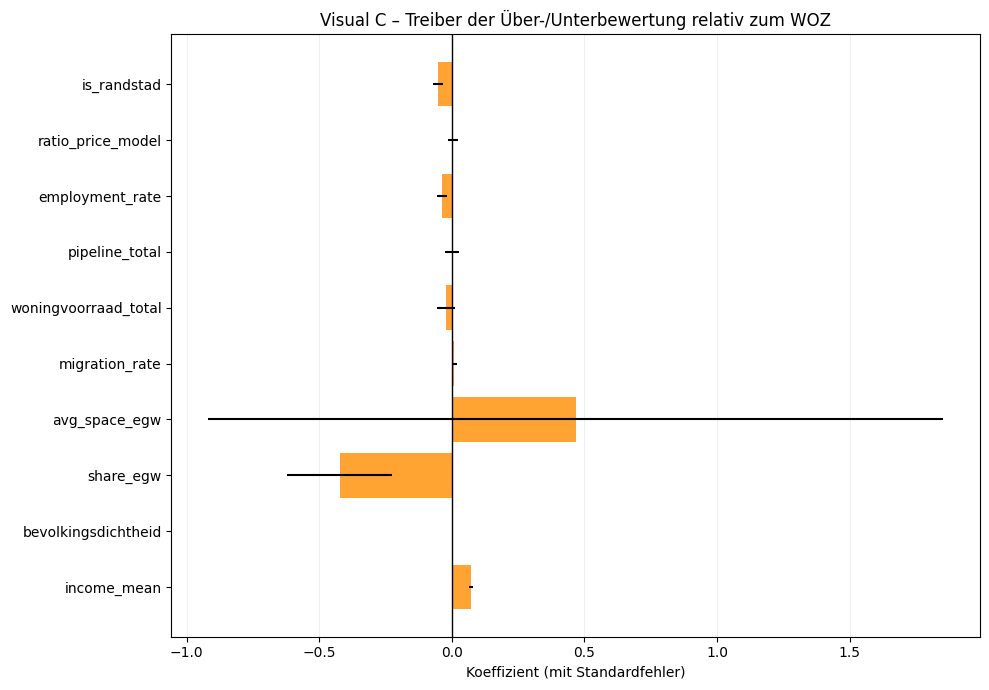

                            OLS Regression Results                            
Dep. Variable:           residual_woz   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     15.84
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           5.78e-19
Time:                        11:32:14   Log-Likelihood:                 160.61
No. Observations:                 156   AIC:                            -299.2
Df Residuals:                     145   BIC:                            -265.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.1272 

In [31]:
# ---------------------------------------------------------
# Visual 12.3. – Residuenmodell: Über-/Unterbewertung relativ zum WOZ
# ---------------------------------------------------------

import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Sicherstellen, dass log-Variablen existieren
df["log_price_total"] = np.log(df["price_total"])
df["log_woz_mean"] = np.log(df["woz_mean"])

# 2. Modell aus Visual B erneut schätzen (für Residuen)
X_B = sm.add_constant(df["log_woz_mean"])
model_B = sm.OLS(df["log_price_total"], X_B, missing="drop").fit()

# 3. Residuen speichern
df["residual_woz"] = model_B.resid

# 4. Strukturvariablen definieren
features_C = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "is_randstad"
]

# 5. Daten bereinigen
df_C = df[["residual_woz"] + features_C].replace([np.inf, -np.inf], np.nan).dropna()

# 6. OLS-Modell für Residuen
X_C = sm.add_constant(df_C[features_C])
y_C = df_C["residual_woz"]

model_C = sm.OLS(y_C, X_C).fit()

# 7. Koeffizienten extrahieren
coef_C = model_C.params[1:]
errors_C = model_C.bse[1:]

# 8. Visualisierung
plt.figure(figsize=(10, 7))

plt.barh(
    coef_C.index,
    coef_C.values,
    xerr=errors_C.values,
    color="darkorange",
    alpha=0.8
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Visual C – Treiber der Über-/Unterbewertung relativ zum WOZ")
plt.xlabel("Koeffizient (mit Standardfehler)")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 9. Modellgüte ausgeben
print(model_C.summary())


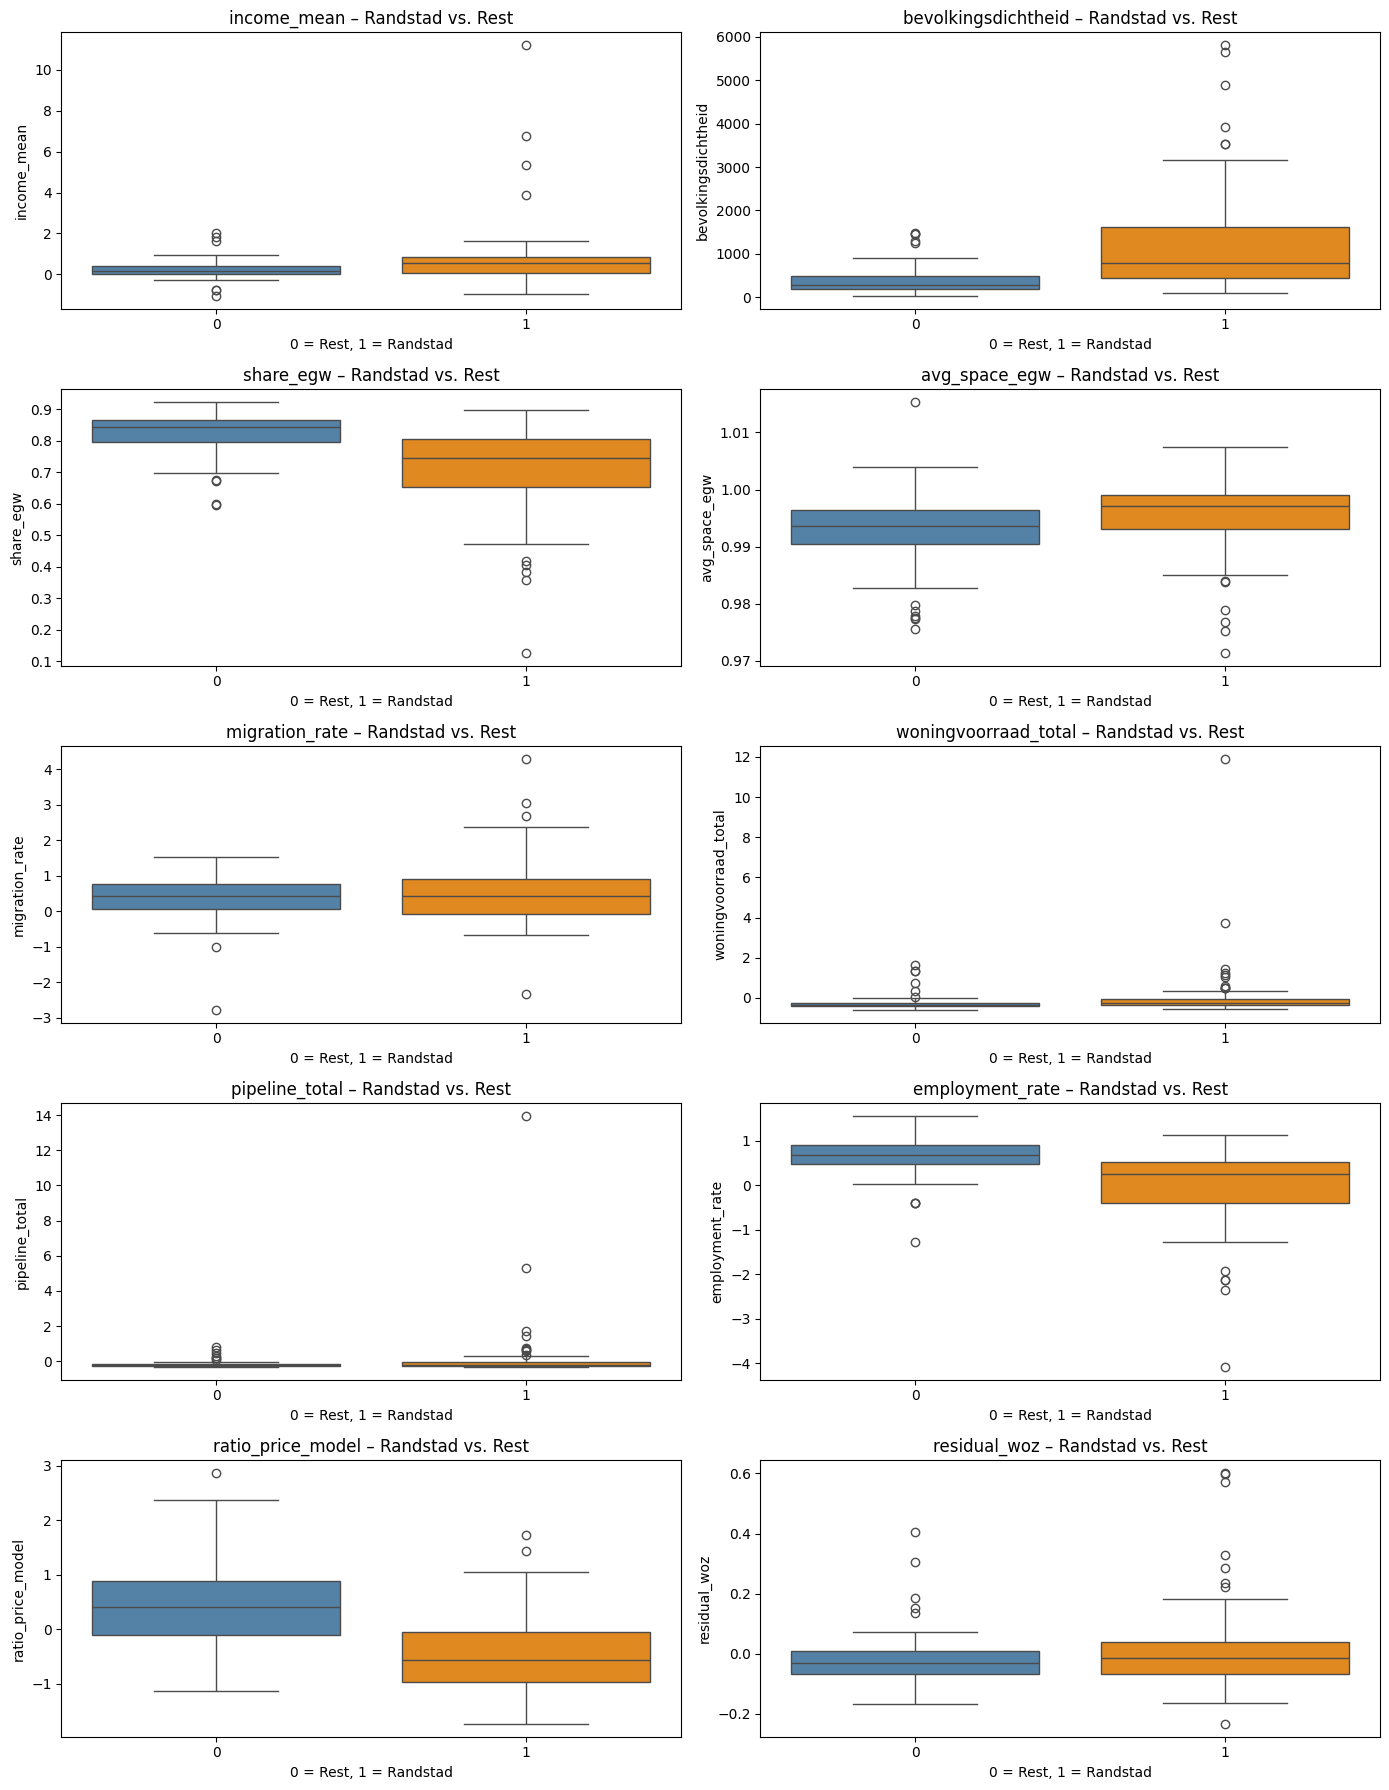

Mittelwerte Randstad (1) vs. Rest (0):


,income_mean,bevolkingsdichtheid,share_egw,avg_space_egw,migration_rate,woningvoorraad_total,pipeline_total,employment_rate,ratio_price_model,residual_woz
is_randstad,,,,,,,,,,
0,0.232511,404.972222,0.822912,0.992801,0.391349,-0.230401,-0.165562,0.663907,0.381302,-0.016528
1,0.776565,1292.297619,0.714793,0.995067,0.527858,0.049810,0.152414,0.031763,-0.448074,0.014167


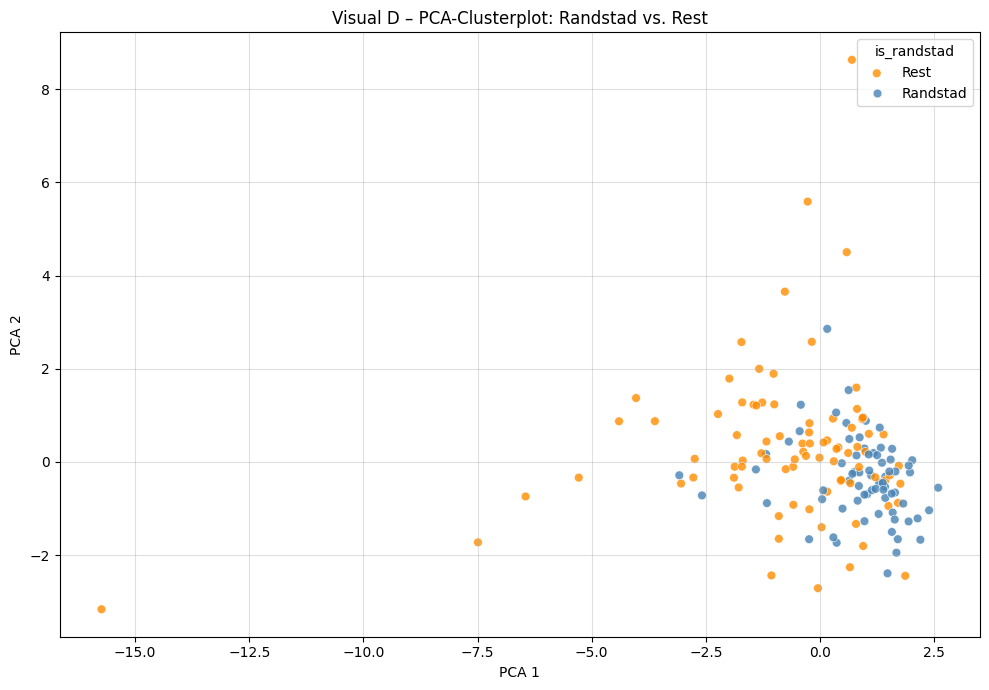

In [34]:
# ---------------------------------------------------------
# Visual 12.4. – Randstad vs. Rest (Clusteranalyse)
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# 1. Strukturvariablen definieren
features_D = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "residual_woz"
]

# 2. Daten bereinigen
df_D = df[["is_randstad"] + features_D].replace([np.inf, -np.inf], np.nan).dropna()

# 3. Boxplots für jede Variable
plt.figure(figsize=(14, 18))
for i, col in enumerate(features_D, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(
        data=df_D,
        x="is_randstad",
        y=col,
        hue="is_randstad",
        palette=["steelblue", "darkorange"],
        legend=False
    )
    plt.title(f"{col} – Randstad vs. Rest")
    plt.xlabel("0 = Rest, 1 = Randstad")
    plt.tight_layout()
plt.show()

# 4. Mittelwertvergleich
mean_table = df_D.groupby("is_randstad")[features_D].mean()
print("Mittelwerte Randstad (1) vs. Rest (0):")
display(mean_table)

# 5. PCA für 2D-Clusterplot
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_D[features_D])

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

df_D["pca1"] = pca_coords[:, 0]
df_D["pca2"] = pca_coords[:, 1]

# 6. PCA-Scatterplot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_D,
    x="pca1",
    y="pca2",
    hue="is_randstad",
    palette=["steelblue", "darkorange"],
    alpha=0.8,
    s=40
)

plt.title("Visual D – PCA-Clusterplot: Randstad vs. Rest")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.4)
plt.legend(title="is_randstad", labels=["Rest", "Randstad"])

plt.tight_layout()
plt.show()
